# VeRA 交互教学

配套 lecture：[`../lectures/04-vera.md`](../lectures/04-vera.md)  
配套论文：[`../papers/04-vera-2024.pdf`](../papers/04-vera-2024.pdf)

本 notebook 演示：
1. 环境检查
2. 共享冻结 A、B + 可训练对角 Λ_b、Λ_d
3. 参数量极致压缩（VeRA r=256 vs LoRA r=8/r=256）
4. peft 调包对照
5. mini training
6. 思考题

In [1]:
import sys
from pathlib import Path
import torch
print(f'torch: {torch.__version__}')

torch: 2.13.0.dev20260602+cu130


## 2. VeRA 结构

公式 (1): h = W_0 x + α/r · Λ_d ⊙ (B (Λ_b ⊙ (A x)))，其中 A、B 冻结共享，Λ 可训练每层独立。

In [2]:
src_dir = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from vera_minimal import VeRAGPT2, VeRALinear, VeRASharedBuffers
from common import print_param_summary

torch.manual_seed(42)
vera = VeRAGPT2(r=256, d_initial=0.1)
print_param_summary(vera, 'VeRA (r=256)')

layer0 = vera.lm.transformer.h[0].attn.c_attn
print(f'\nlayer 0 Λ:')
print(f'  Λ_b shape: {tuple(layer0.Lambda_b.shape)}, 初始 = {layer0.Lambda_b[:4].tolist()}')
print(f'  Λ_d shape: {tuple(layer0.Lambda_d.shape)}, 初始 = {layer0.Lambda_d[:4].tolist()}')

print(f'\n共享 A、B（不计入 trainable）:')
A = VeRASharedBuffers.get_A(256, 768)
B = VeRASharedBuffers.get_B(256, 2304)
print(f'  A shape: {tuple(A.shape)}, A[:3,:3] = {A[:3, :3]}')
print(f'  B shape: {tuple(B.shape)}')

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16779.48it/s]

  VeRA (r=256)
  Total params:      124,470,528
  Trainable params:       30,720  (0.0247%)
  Frozen params:     124,439,808

layer 0 Λ:
  Λ_b shape: (256,), 初始 = [1.0, 1.0, 1.0, 1.0]
  Λ_d shape: (2304,), 初始 = [0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612]

共享 A、B（不计入 trainable）:
  A shape: (256, 768), A[:3,:3] = tensor([[ 0.1170,  0.1271, -0.0359],
        [-0.0985,  0.1513,  0.0585],
        [ 0.0223, -0.0470, -0.0790]])
  B shape: (2304, 256)


## 3. 参数量压缩演示

C:\Users\ericp\AppData\Local\Temp\ipykernel_41252\108830434.py:24: UserWarning: Glyph 40644 (\N{CJK UNIFIED IDEOGRAPH-9EC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41252\108830434.py:24: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41252\108830434.py:24: UserWarning: Glyph 34013 (\N{CJK UNIFIED IDEOGRAPH-84DD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41252\108830434.py:24: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41252\108830434.py:24: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41252\108830434.py:24: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDE

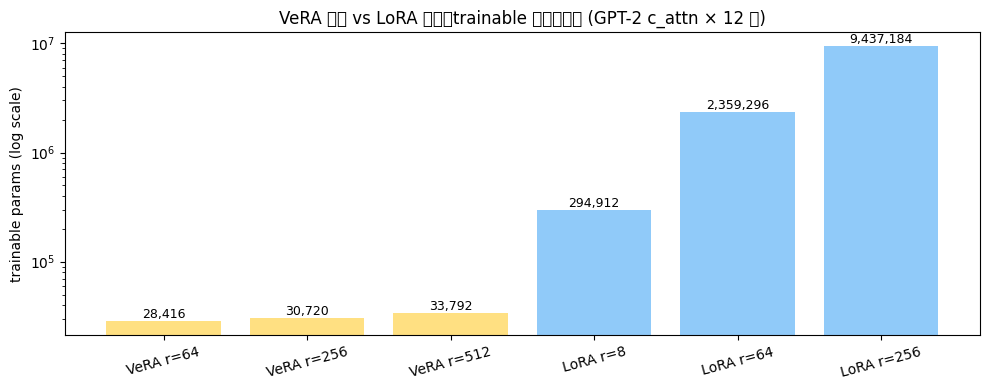


VeRA r=256 vs LoRA r=8: 30,720 vs 294,912
  → VeRA 节省 9.6x


In [3]:
import matplotlib.pyplot as plt

methods = [
    ('VeRA r=64',  12 * (64 + 2304)),
    ('VeRA r=256', 12 * (256 + 2304)),
    ('VeRA r=512', 12 * (512 + 2304)),
    ('LoRA r=8',   12 * (8*768 + 2304*8)),
    ('LoRA r=64',  12 * (64*768 + 2304*64)),
    ('LoRA r=256', 12 * (256*768 + 2304*256)),
]
names = [m[0] for m in methods]
params = [m[1] for m in methods]
colors = ['#ffe082']*3 + ['#90caf9']*3

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(names, params, color=colors)
for bar, p in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{p:,}', ha='center', va='bottom', fontsize=9)
ax.set_yscale('log')
ax.set_ylabel('trainable params (log scale)')
ax.set_title('VeRA 黄色 vs LoRA 蓝色：trainable 参数量对比 (GPT-2 c_attn × 12 层)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f'\nVeRA r=256 vs LoRA r=8: {12*(256+2304):,} vs {12*(8*768+2304*8):,}')
print(f'  → VeRA 节省 {(12*(8*768+2304*8)) / (12*(256+2304)):.1f}x')

## 4. peft 调包对照

In [4]:
from vera_peft import build_peft_model

torch.manual_seed(42)
peft_vera = build_peft_model(r=256, d_initial=0.1)
print_param_summary(peft_vera, 'peft VeRA (r=256)')

print('\npeft 内部参数：')
for name, p in peft_vera.named_parameters():
    if 'h.0.attn.c_attn.vera' in name:
        print(f'  {name}: shape={tuple(p.shape)}')
print('\n注意：peft 的 vera_lambda_b/vera_lambda_d 命名与论文相反，但功能等价')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17253.79it/s]

W0603 15:54:50.734000 41252 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


  peft VeRA (r=256)
  Total params:      124,470,528
  Trainable params:       30,720  (0.0247%)
  Frozen params:     124,439,808

peft 内部参数：
  base_model.model.transformer.h.0.attn.c_attn.vera_lambda_b.default: shape=(2304,)
  base_model.model.transformer.h.0.attn.c_attn.vera_lambda_d.default: shape=(256,)

注意：peft 的 vera_lambda_b/vera_lambda_d 命名与论文相反，但功能等价


C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\vera\model.py:275: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 5. Mini training

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17026.17it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


C:\Users\ericp\AppData\Local\Temp\ipykernel_41252\720223797.py:31: UserWarning: Glyph 20165 (\N{CJK UNIFIED IDEOGRAPH-4EC5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20165 (\N{CJK UNIFIED IDEOGRAPH-4EC5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


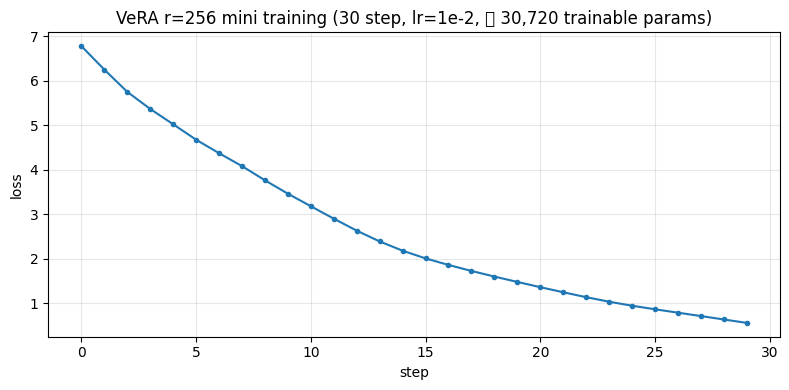

final loss: 0.5625


In [5]:
torch.manual_seed(42)
vera = VeRAGPT2(r=256, d_initial=0.1)

tok = vera.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing product',
    'absolutely terrible movie',
    'fantastic experience'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

optimizer = torch.optim.AdamW(
    [p for p in vera.parameters() if p.requires_grad], lr=1e-2
)

losses = []
for step in range(30):
    optimizer.zero_grad()
    out = vera(**inputs)
    out.loss.backward()
    optimizer.step()
    losses.append(out.loss.item())

plt.figure(figsize=(8, 4))
plt.plot(losses, marker='o', markersize=3)
plt.xlabel('step')
plt.ylabel('loss')
plt.title(f'VeRA r=256 mini training (30 step, lr=1e-2, 仅 {sum(p.numel() for p in vera.parameters() if p.requires_grad):,} trainable params)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'final loss: {losses[-1]:.4f}')

## 6. 思考题

1. **公式题**：证明 VeRA 的 ΔW = Λ_d ⊙ (B diag(Λ_b) A) 可以表示成 d×d 矩阵，写出 (i,j) 元素表达式。
2. **公式题**：推导 ∂L/∂Λ_b[i]。哪些项贡献？
3. **代码题**：让 Λ_d 用 Gaussian 初始化跑 mini training。
4. **设计题**：若不共享 A、B，参数量怎么变？跑实验验证。
5. **对比题**：VeRA r+d vs Prompt Tuning p·d，何时谁更省？
6. **实践题**：调 r=64 / 256 / 512，看 mini training loss 收敛差异。